In [1]:
#import required packages
import numpy as np
import geopandas as gpd
import rasterio
from shapely.geometry import LineString
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

#open the observed data, select sheet and clip columns
dfRaw = pd.read_excel('../l0rawData/Csv/Observed_Head.xlsx', sheet_name='Water Level Head & Temp')
dfRaw = dfRaw.rename(columns={'Unnamed: 41':'ElevRaw'})
dfRaw = dfRaw.iloc[2:,40:42]
dfRaw = dfRaw.set_index('SW1')
dfRaw['waterStage'] = dfRaw.ElevRaw + 3.4 #fix on the datum
dfRaw.head()

/home/hatari/.local/lib/python3.12/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,ElevRaw,waterStage
SW1,,
2023-01-01 00:00:00,145.511681,148.911681
2023-01-01 01:00:00,145.526299,148.926299
2023-01-01 02:00:00,145.543689,148.943689
2023-01-01 03:00:00,145.555649,148.955649
2023-01-01 04:00:00,145.570253,148.970253


<AxesSubplot: xlabel='SW1'>

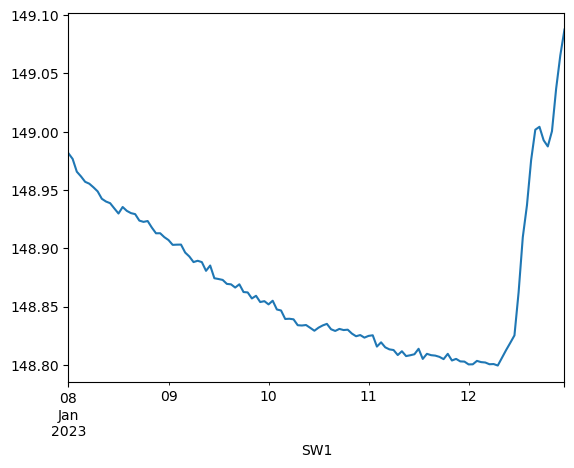

In [3]:
dfRaw.loc['2023-01-08':'2023-01-12', 'waterStage'].plot()

<AxesSubplot: xlabel='SW1'>

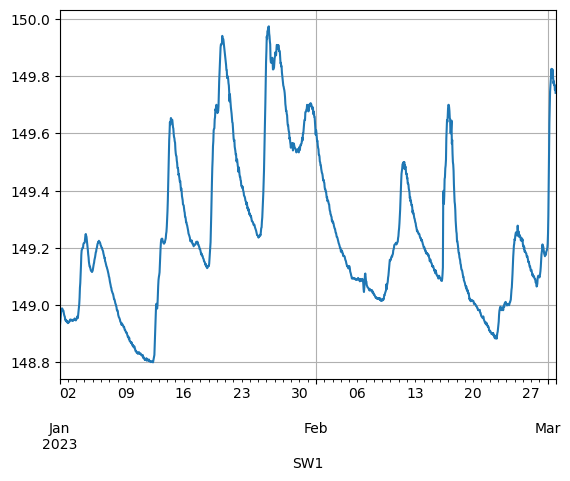

In [4]:
dfRaw['waterStage'].plot(grid=True)

In [5]:
#!pip install h5py --break-system-packages
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

In [6]:
hdfPath = '../l2simulations/theisNash_v0a/theisNash_v0a.p01.hdf'
AreaName = '2D Flow Area'

In [7]:
sw1Df = gpd.read_file('../l1processedData/Shp/Model/SW1.shp')
sw1Coords = list(sw1Df.iloc[0].geometry.coords)[0]
sw1Coords

(697308.6910000006, 4345781.995000001)

In [8]:
hdf = h5py.File(hdfPath,'r')

#cellInfoPath = f"Geometry/2D Flow Areas/{AreaName}/Cells Center Coordinate"
#cellCentroids = hdf[cellInfoPath][:]

cellCentroidsArray = np.asarray(hdf['Geometry']['2D Flow Areas']['Cell Points'])
cellCentroidsArray[:5]

array([[ 697201.05260369, 4345908.25749028],
       [ 697203.05260369, 4345908.25749028],
       [ 697201.05260369, 4345906.25749028],
       [ 697203.05260369, 4345906.25749028],
       [ 697205.05260369, 4345906.25749028]])

In [9]:
spatialIndex = KDTree(cellCentroidsArray)

In [10]:
timeBlocks = hdf['Results']['Unsteady']['Output']['Output Blocks']['Base Output']['Unsteady Time Series']['Time Date Stamp']
timeBlocksList = []
for timeBlock in timeBlocks:
    timeString = timeBlock.decode('utf-8').strip()
    timeDf = pd.to_datetime(timeString, format='%d%b%Y %H:%M:%S')
    timeBlocksList.append(timeDf)
timeBlocksList[:5]

[Timestamp('2023-01-08 00:00:00'),
 Timestamp('2023-01-08 00:20:00'),
 Timestamp('2023-01-08 00:40:00'),
 Timestamp('2023-01-08 01:00:00'),
 Timestamp('2023-01-08 01:20:00')]

In [11]:
surfaceDataset = hdf['Results']['Unsteady']['Output']['Output Blocks']['Base Output']['Unsteady Time Series']['2D Flow Areas']['Perimeter 1']['Water Surface']
surfaceDatasetArray = np.asarray(surfaceDataset)
surfaceDatasetArray[:2]

array([[149.16469, 150.82022, 149.16469, ..., 149.48186, 153.0691 ,
        149.39035],
       [149.16469, 150.82022, 149.16469, ..., 149.48186, 153.0691 ,
        149.39035]], dtype=float32)

In [12]:
distance, cellIndex = spatialIndex.query(sw1Coords)

In [13]:
print(distance)

0.4468314809539142


In [14]:
print(cellIndex)

6355


In [15]:
#check position 
print(sw1Coords)
print(cellCentroidsArray[cellIndex])

(697308.6910000006, 4345781.995000001)
[ 697309.05260369 4345782.25749028]


In [16]:
#create modeled SW1 dataframe
sw1SimDf = pd.DataFrame()
sw1SimDf['Date'] = timeBlocksList
sw1SimDf['WSE'] = surfaceDatasetArray[:,cellIndex]
sw1SimDf = sw1SimDf.set_index(['Date'])
sw1SimDf.head()


,WSE
Date,
2023-01-08 00:00:00,149.003357
2023-01-08 00:20:00,149.154297
2023-01-08 00:40:00,149.085526
2023-01-08 01:00:00,149.151672
2023-01-08 01:20:00,149.081528


(27885600.0, 27892800.0)

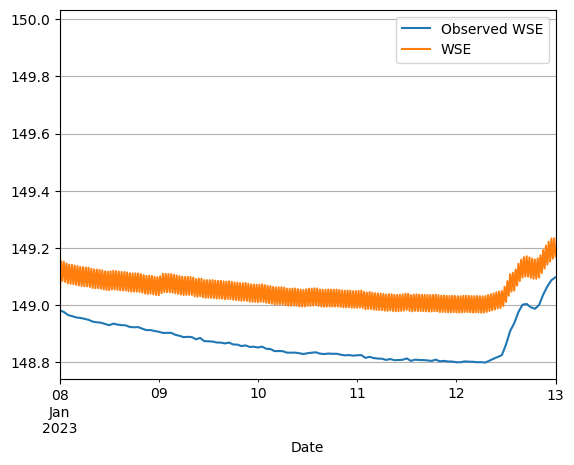

In [17]:
fig, ax = plt.subplots()
dfRaw['waterStage'].plot(ax=ax, label='Observed WSE')
sw1SimDf.plot(ax=ax)
ax.legend()
ax.grid()
ax.set_xlim(sw1SimDf.index[0], sw1SimDf.index[-1])

In [ ]:
sw1SimDf.index[-1]